Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create daily sales time series
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])
daily_sales = daily_sales.sort_values('ds').reset_index(drop=True)

print(f"TIME SERIES READY!\n")
print(f"   Date Range : {daily_sales['ds'].min().date()} → {daily_sales['ds'].max().date()}")
print(f"   Total Days : {len(daily_sales)} days")
print(f"   Avg Daily Revenue : £{daily_sales['y'].mean():,.2f}")
print(f"   Max Daily Revenue : £{daily_sales['y'].max():,.2f}")

TIME SERIES READY!

   Date Range : 2009-12-01 → 2011-12-09
   Total Days : 604 days
   Avg Daily Revenue : £17,670.67
   Max Daily Revenue : £67,734.52


Prophet Model Train

In [5]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

from prophet import Prophet

# Initialize Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

# Train the model
model.fit(daily_sales)

# Create future dataframe (90 days forecast)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print("PROPHET MODEL TRAINED SUCCESSFULLY!")
print(f"\nForecast Summary (Next 90 Days):")
future_only = forecast[forecast['ds'] > daily_sales['ds'].max()]
print(f"   Forecast Start : {future_only['ds'].min().date()}")
print(f"   Forecast End   : {future_only['ds'].max().date()}")
print(f"   Avg Daily      : £{future_only['yhat'].mean():,.2f}")
print(f"   Total Expected : £{future_only['yhat'].sum():,.2f}")
print(f"   Best Day       : {future_only.loc[future_only['yhat'].idxmax(), 'ds'].date()} (£{future_only['yhat'].max():,.2f})")

PROPHET MODEL TRAINED SUCCESSFULLY!

Forecast Summary (Next 90 Days):
   Forecast Start : 2011-12-10
   Forecast End   : 2012-03-08
   Avg Daily      : £11,136.99
   Total Expected : £1,002,329.46
   Best Day       : 2011-12-15 (£23,959.40)


Forecast Visualization

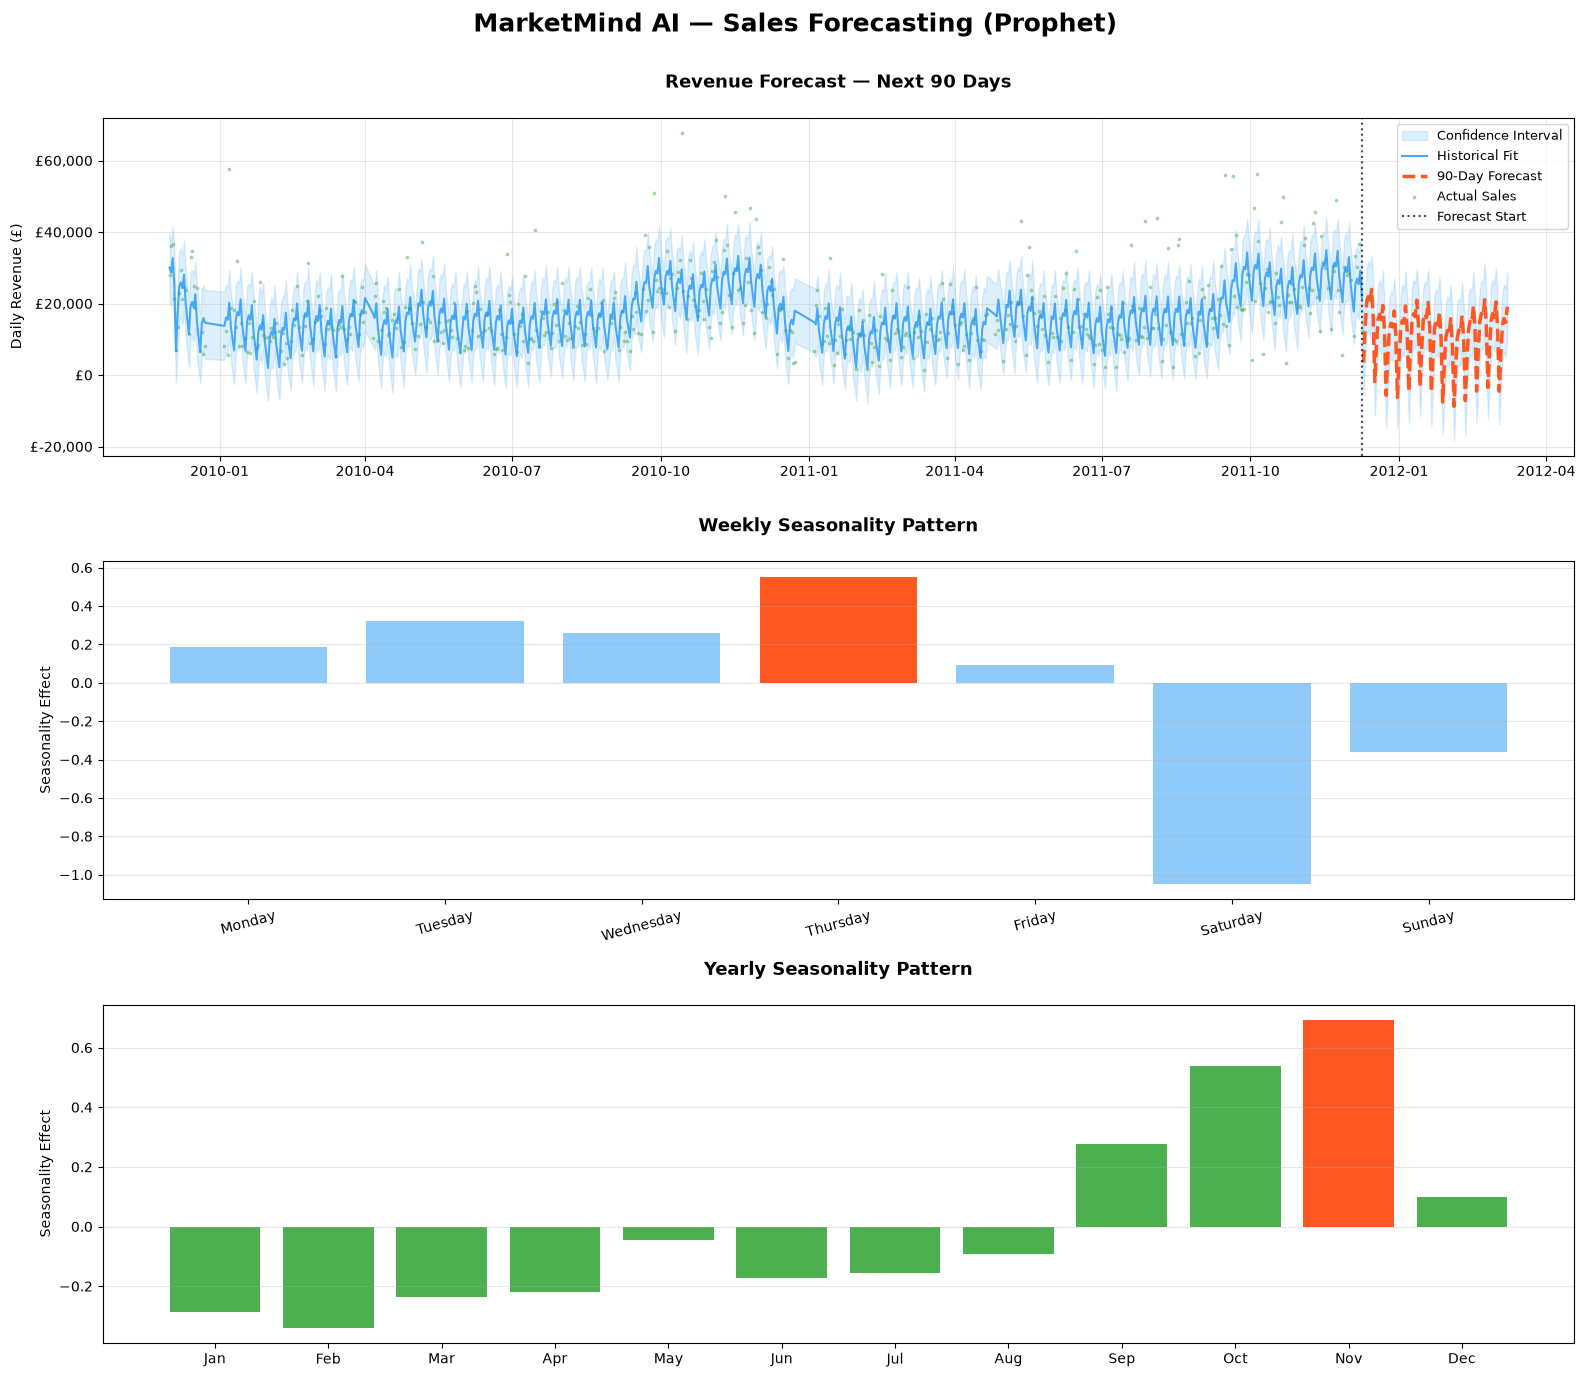

Forecast Chart Saved!


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('MarketMind AI — Sales Forecasting (Prophet)\n', fontsize=18, fontweight='bold')

# Split actual vs forecast
actual = forecast[forecast['ds'] <= daily_sales['ds'].max()]
predicted = forecast[forecast['ds'] > daily_sales['ds'].max()]

# Chart 1: Full Forecast
axes[0].fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.15, color='#2196F3', label='Confidence Interval')
axes[0].plot(actual['ds'], actual['yhat'],
             color='#2196F3', linewidth=1.5, label='Historical Fit', alpha=0.8)
axes[0].plot(predicted['ds'], predicted['yhat'],
             color='#FF5722', linewidth=2.5, label='90-Day Forecast', linestyle='--')
axes[0].scatter(daily_sales['ds'], daily_sales['y'],
                color='#4CAF50', s=3, alpha=0.4, label='Actual Sales')
axes[0].axvline(x=daily_sales['ds'].max(), color='black',
                linestyle=':', linewidth=1.5, alpha=0.7, label='Forecast Start')
axes[0].set_title('Revenue Forecast — Next 90 Days\n', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Revenue (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Chart 2: Weekly Seasonality
weekly = model.predict(model.make_future_dataframe(periods=7))
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_effect = forecast.groupby(forecast['ds'].dt.dayofweek)['weekly'].mean()
bar_colors = ['#FF5722' if i == weekly_effect.idxmax() else '#90CAF9' for i in range(7)]
axes[1].bar(day_names, weekly_effect.values, color=bar_colors)
axes[1].set_title('Weekly Seasonality Pattern\n', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seasonality Effect')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

# Chart 3: Yearly Seasonality
yearly_effect = forecast.groupby(forecast['ds'].dt.month)['yearly'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors2 = ['#FF5722' if i == yearly_effect.idxmax() else '#4CAF50' for i in range(1,13)]
axes[2].bar(month_names, yearly_effect.values, color=bar_colors2)
axes[2].set_title('Yearly Seasonality Pattern\n', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Seasonality Effect')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forecast Chart Saved!")